In [15]:
# =============================================================================
# BREAST ULTRASOUND IMAGE CLASSIFICATION (BUSI Dataset)
# Normal vs Benign vs Malignant  |  Kaggle Notebook
# Dataset: /kaggle/input/breast-ultrasound-images-dataset/Dataset_BUSI_with_GT
#           ├── benign/      (PNG images + _mask.png files)
#           ├── malignant/   (PNG images + _mask.png files)
#           └── normal/      (PNG images + _mask.png files)
# =============================================================================

import os, random, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from collections import Counter

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import transforms, models
from torchvision.utils import make_grid

from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_curve, auc, precision_recall_fscore_support
)
from sklearn.preprocessing import label_binarize

warnings.filterwarnings("ignore")
torch.manual_seed(42); np.random.seed(42); random.seed(42)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"✅  Running on: {DEVICE}")

✅  Running on: cuda


In [16]:
DATA_DIR  = Path("/kaggle/input/datasets/aryashah2k/breast-ultrasound-images-dataset/Dataset_BUSI_with_GT")
CLASSES   = ["normal", "benign", "malignant"]   # order defines label index
CLASS2IDX = {c: i for i, c in enumerate(CLASSES)}

# Verify folders exist before proceeding
print("\n── Dataset folder check ──")
for cls in CLASSES:
    folder = DATA_DIR / cls
    all_pngs  = list(folder.glob("*.png"))
    img_pngs  = [f for f in all_pngs if "mask" not in f.stem]
    mask_pngs = [f for f in all_pngs if "mask" in f.stem]
    print(f"  {cls:10s}  images={len(img_pngs):3d}  masks={len(mask_pngs):3d}  "
          f"  path_ok={folder.exists()}")


── Dataset folder check ──
  normal      images=133  masks=133    path_ok=True
  benign      images=437  masks=454    path_ok=True
  malignant   images=210  masks=211    path_ok=True


In [17]:
def build_filelist(data_dir: Path, classes: list) -> pd.DataFrame:
    """
    Walk each class sub-folder under data_dir.
    Collect every .png that does NOT contain 'mask' in its filename stem.
    Returns a DataFrame with columns: path | label | label_idx
    """
    records = []
    for cls in classes:
        folder = data_dir / cls
        for fp in sorted(folder.glob("*.png")):
            if "mask" not in fp.stem:          # ← exclude ground-truth masks
                records.append({
                    "path":      str(fp),
                    "label":     cls,
                    "label_idx": CLASS2IDX[cls]
                })
    return pd.DataFrame(records)


df = build_filelist(DATA_DIR, CLASSES)

print(f"\nTotal images (no masks): {len(df)}")
print("\nPer-class counts:")
print(df["label"].value_counts().to_string())


Total images (no masks): 780

Per-class counts:
label
benign       437
malignant    210
normal       133


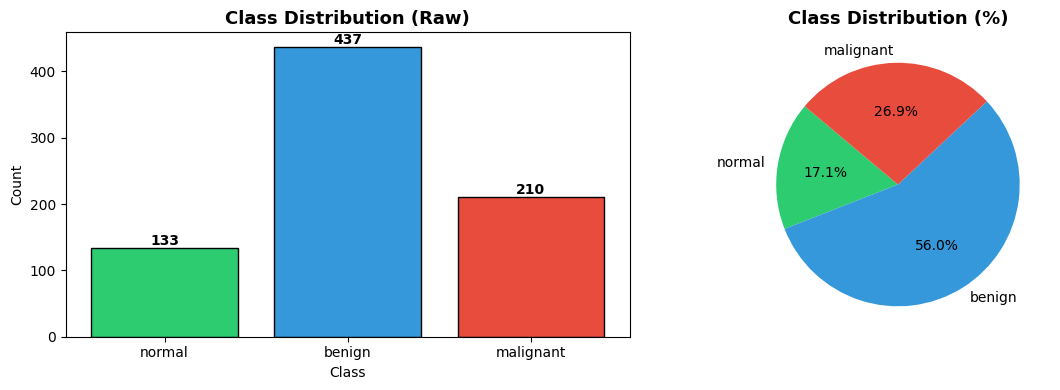


── Imbalance Ratios ──
  Benign / Normal    : 3.29×
  Benign / Malignant : 2.08×
  Max / Min          : 3.29×


In [18]:
# Preserve CLASSES order (normal → benign → malignant)
counts = df["label"].value_counts()[CLASSES]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
colors = ["#2ecc71", "#3498db", "#e74c3c"]     # green=normal, blue=benign, red=malignant

# ── Bar chart ──
axes[0].bar(counts.index, counts.values, color=colors, edgecolor="black")
axes[0].set_title("Class Distribution (Raw)", fontsize=13, fontweight="bold")
axes[0].set_xlabel("Class"); axes[0].set_ylabel("Count")
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 5, str(v), ha="center", fontweight="bold")

# ── Pie chart ──
axes[1].pie(counts.values, labels=counts.index, autopct="%1.1f%%",
            colors=colors, startangle=140)
axes[1].set_title("Class Distribution (%)", fontsize=13, fontweight="bold")

plt.tight_layout()
plt.savefig("class_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

# Print imbalance ratios
print("\n── Imbalance Ratios ──")
print(f"  Benign / Normal    : {counts['benign']  / counts['normal']:.2f}×")
print(f"  Benign / Malignant : {counts['benign']  / counts['malignant']:.2f}×")
print(f"  Max / Min          : {counts.max() / counts.min():.2f}×")

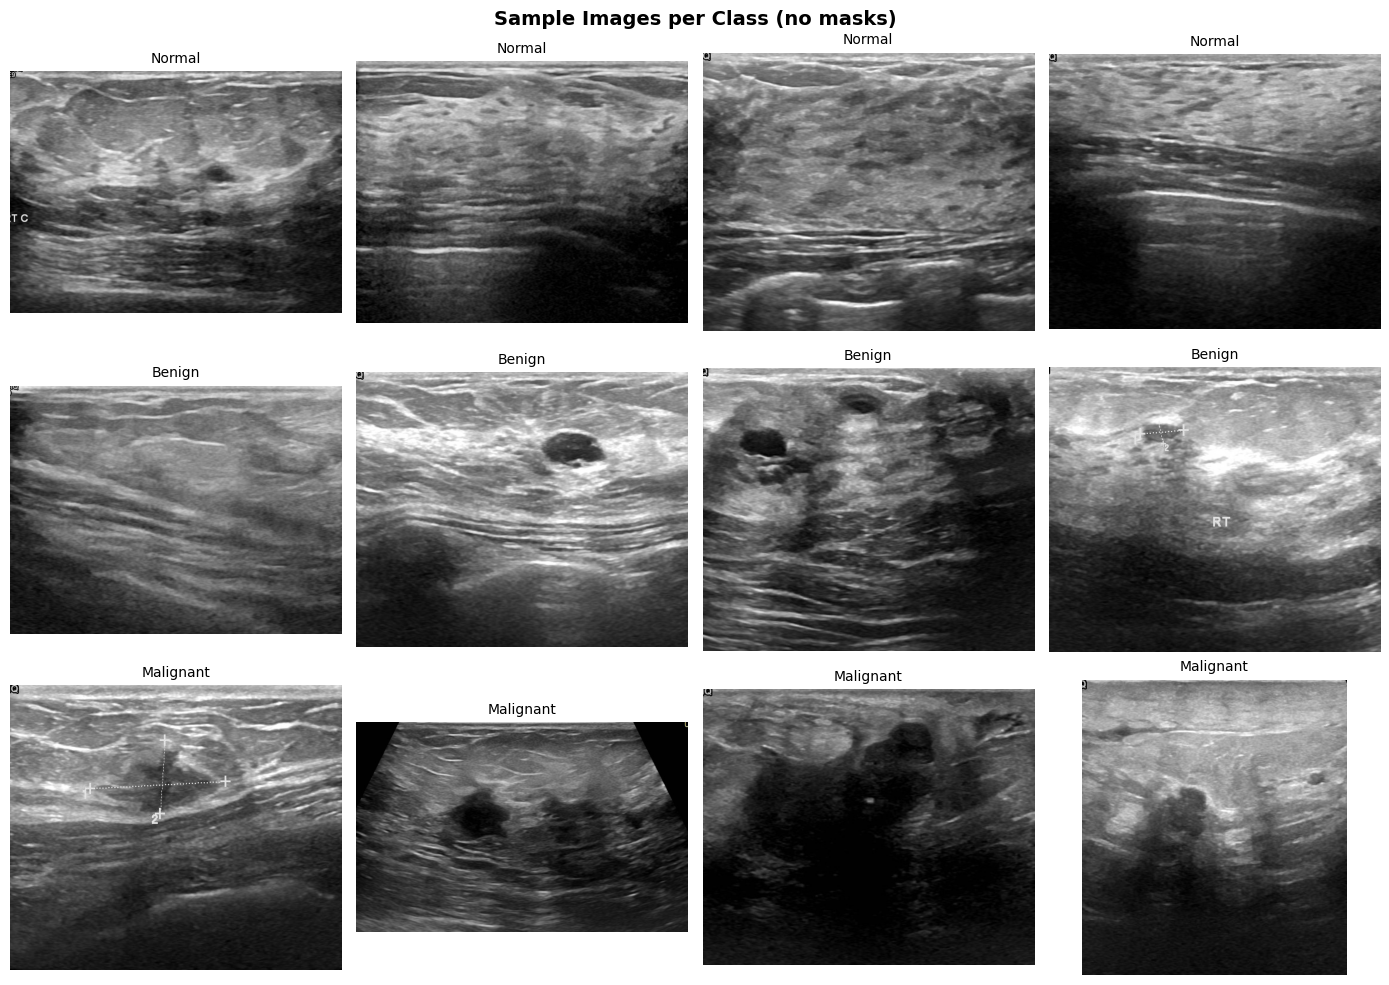

In [19]:
fig, axes = plt.subplots(3, 4, figsize=(14, 10))

for row, cls in enumerate(CLASSES):
    subset = df[df["label"] == cls].sample(4, random_state=42)
    for col, (_, rec) in enumerate(subset.iterrows()):
        img = Image.open(rec["path"]).convert("RGB")
        axes[row][col].imshow(img, cmap="gray")
        axes[row][col].set_title(f"{cls.capitalize()}", fontsize=10)
        axes[row][col].axis("off")

plt.suptitle("Sample Images per Class (no masks)", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("sample_images.png", dpi=150, bbox_inches="tight")
plt.show()

In [20]:
train_df, temp_df = train_test_split(
    df, test_size=0.30, stratify=df["label"], random_state=42
)
val_df, test_df = train_test_split(
    temp_df, test_size=0.50, stratify=temp_df["label"], random_state=42
)

print("── Split sizes ──")
for name, sdf in [("Train", train_df), ("Val", val_df), ("Test", test_df)]:
    dist = dict(sdf["label"].value_counts()[CLASSES])
    print(f"  {name:5s}: {len(sdf):4d}  {dist}")

── Split sizes ──
  Train:  546  {'normal': np.int64(93), 'benign': np.int64(306), 'malignant': np.int64(147)}
  Val  :  117  {'normal': np.int64(20), 'benign': np.int64(65), 'malignant': np.int64(32)}
  Test :  117  {'normal': np.int64(20), 'benign': np.int64(66), 'malignant': np.int64(31)}


In [21]:
IMG_SIZE = 224

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.3),
    transforms.RandomRotation(degrees=20),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2, hue=0.05),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1), scale=(0.9, 1.1)),
    transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 1.5)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std =[0.229, 0.224, 0.225]),
])

val_test_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std =[0.229, 0.224, 0.225]),
])

In [22]:
class BUSIDataset(Dataset):
    """
    Loads breast ultrasound PNG images from a DataFrame.
    Each row must have: path (str), label_idx (int).
    Applies transform if provided.
    """
    def __init__(self, dataframe: pd.DataFrame, transform=None):
        self.df        = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row   = self.df.iloc[idx]
        img   = Image.open(row["path"]).convert("RGB")   # PNG → RGB (3-channel)
        label = int(row["label_idx"])
        if self.transform:
            img = self.transform(img)
        return img, label


train_ds = BUSIDataset(train_df, train_transform)
val_ds   = BUSIDataset(val_df,   val_test_transform)
test_ds  = BUSIDataset(test_df,  val_test_transform)

print(f"Train dataset : {len(train_ds)} samples")
print(f"Val   dataset : {len(val_ds)}   samples")
print(f"Test  dataset : {len(test_ds)}  samples")

Train dataset : 546 samples
Val   dataset : 117   samples
Test  dataset : 117  samples



── Class weights for sampler ──
  normal      count= 93  weight=0.01075
  benign      count=306  weight=0.00327
  malignant   count=147  weight=0.00680


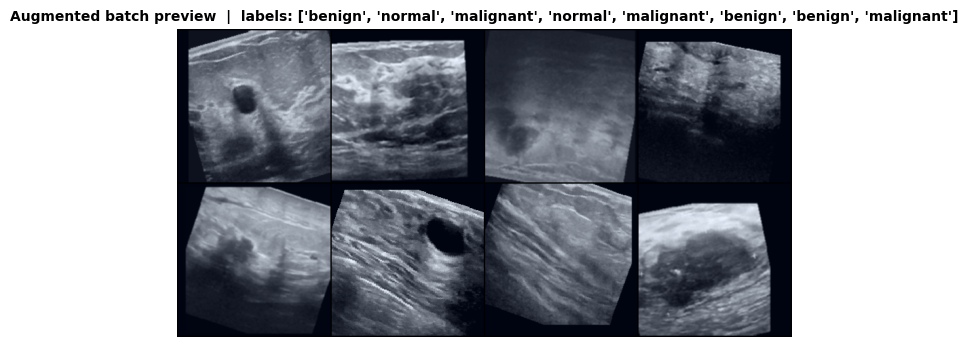

In [23]:
# Count how many samples of each class are in the training set
class_counts_train = (
    train_df["label_idx"].value_counts().sort_index().values
)   # shape [3]

# Weight per class = 1 / class_count  (rarer class → higher weight)
class_weights = 1.0 / class_counts_train.astype(float)

# Assign per-sample weight
sample_weights = [class_weights[lbl] for lbl in train_df["label_idx"].values]

sampler = WeightedRandomSampler(
    weights     = sample_weights,
    num_samples = len(sample_weights),
    replacement = True
)

print("\n── Class weights for sampler ──")
for cls, w, cnt in zip(CLASSES, class_weights, class_counts_train):
    print(f"  {cls:10s}  count={cnt:3d}  weight={w:.5f}")

BATCH = 32
train_loader = DataLoader(train_ds, batch_size=BATCH, sampler=sampler,
                          num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH, shuffle=False,
                          num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH, shuffle=False,
                          num_workers=2, pin_memory=True)

# ── Preview one augmented batch ──
sample_imgs, sample_lbls = next(iter(train_loader))
grid = make_grid(sample_imgs[:8], nrow=4, normalize=True)
plt.figure(figsize=(12, 4))
plt.imshow(grid.permute(1, 2, 0).numpy())
plt.title(f"Augmented batch preview  |  labels: {[CLASSES[l] for l in sample_lbls[:8].tolist()]}",
          fontsize=10, fontweight="bold")
plt.axis("off")
plt.savefig("augmented_samples.png", dpi=150, bbox_inches="tight")
plt.show()

In [24]:
def build_model(num_classes: int = 3) -> nn.Module:
    """
    EfficientNet-B0 pretrained on ImageNet.
    Freeze early layers; unfreeze features[6:] for domain adaptation.
    Replace classifier head with a 2-layer MLP + dropout.
    """
    model = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.DEFAULT)

    # Freeze all first
    for param in model.parameters():
        param.requires_grad = False

    # Unfreeze last 3 MBConv blocks + final BN layer
    for param in model.features[6:].parameters():
        param.requires_grad = True

    # Custom classifier head
    in_features = model.classifier[1].in_features   # 1280 for B0
    model.classifier = nn.Sequential(
        nn.Dropout(p=0.4),
        nn.Linear(in_features, 256),
        nn.ReLU(inplace=True),
        nn.Dropout(p=0.3),
        nn.Linear(256, num_classes)
    )
    return model.to(DEVICE)


model = build_model(num_classes=3)

total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nTotal params    : {total_params:,}")
print(f"Trainable params: {trainable_params:,}")


Total params    : 4,336,255
Trainable params: 3,484,447


In [25]:
# Inverse-frequency weights: rarer class → larger penalty for misclassification
total_train = len(train_df)
loss_weights = torch.tensor(
    [total_train / (3.0 * cnt) for cnt in class_counts_train],
    dtype=torch.float
).to(DEVICE)

criterion = nn.CrossEntropyLoss(weight=loss_weights)

print("\n── CrossEntropyLoss class weights ──")
for cls, w in zip(CLASSES, loss_weights.cpu().numpy()):
    print(f"  {cls:10s}: {w:.4f}")


── CrossEntropyLoss class weights ──
  normal    : 1.9570
  benign    : 0.5948
  malignant : 1.2381


In [26]:
optimizer = optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=1e-4,
    weight_decay=1e-4
)
scheduler = optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=30, eta_min=1e-6
)

In [27]:
EPOCHS       = 30
PATIENCE     = 7
best_val_acc = 0.0
patience_cnt = 0
history      = {"train_loss": [], "val_loss": [],
                "train_acc":  [], "val_acc": []}


def run_epoch(loader: DataLoader, train: bool = True):
    model.train() if train else model.eval()
    total_loss = correct = total = 0

    ctx = torch.enable_grad() if train else torch.no_grad()
    with ctx:
        for imgs, labels in loader:
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
            if train:
                optimizer.zero_grad()
            logits = model(imgs)
            loss   = criterion(logits, labels)
            if train:
                loss.backward()
                optimizer.step()
            total_loss += loss.item() * imgs.size(0)
            correct    += (logits.argmax(1) == labels).sum().item()
            total      += imgs.size(0)

    return total_loss / total, correct / total


print("── Training started ──\n")
for epoch in range(1, EPOCHS + 1):
    t_loss, t_acc = run_epoch(train_loader, train=True)
    v_loss, v_acc = run_epoch(val_loader,   train=False)
    scheduler.step()

    history["train_loss"].append(t_loss); history["val_loss"].append(v_loss)
    history["train_acc"].append(t_acc);   history["val_acc"].append(v_acc)

    # Save best checkpoint
    if v_acc > best_val_acc:
        best_val_acc = v_acc
        torch.save(model.state_dict(), "best_model.pth")
        patience_cnt = 0
        flag = "✅ saved"
    else:
        patience_cnt += 1
        flag = f"patience {patience_cnt}/{PATIENCE}"

    if epoch % 5 == 0 or epoch == 1:
        print(f"Epoch {epoch:3d}/{EPOCHS}  |  "
              f"Train Loss={t_loss:.4f} Acc={t_acc:.4f}  |  "
              f"Val Loss={v_loss:.4f} Acc={v_acc:.4f}  |  {flag}")

    if patience_cnt >= PATIENCE:
        print(f"\n⚠  Early stopping triggered at epoch {epoch}")
        break

print(f"\nBest Validation Accuracy: {best_val_acc:.4f}")

── Training started ──

Epoch   1/30  |  Train Loss=1.0324 Acc=0.3919  |  Val Loss=1.0852 Acc=0.2137  |  ✅ saved
Epoch   5/30  |  Train Loss=0.6330 Acc=0.6319  |  Val Loss=0.7295 Acc=0.6325  |  ✅ saved
Epoch  10/30  |  Train Loss=0.4467 Acc=0.7582  |  Val Loss=0.6293 Acc=0.6923  |  patience 1/7
Epoch  15/30  |  Train Loss=0.4222 Acc=0.7930  |  Val Loss=0.5517 Acc=0.7094  |  ✅ saved
Epoch  20/30  |  Train Loss=0.3837 Acc=0.7857  |  Val Loss=0.5444 Acc=0.7094  |  patience 1/7
Epoch  25/30  |  Train Loss=0.3356 Acc=0.8278  |  Val Loss=0.5424 Acc=0.6838  |  patience 6/7

⚠  Early stopping triggered at epoch 26

Best Validation Accuracy: 0.7350


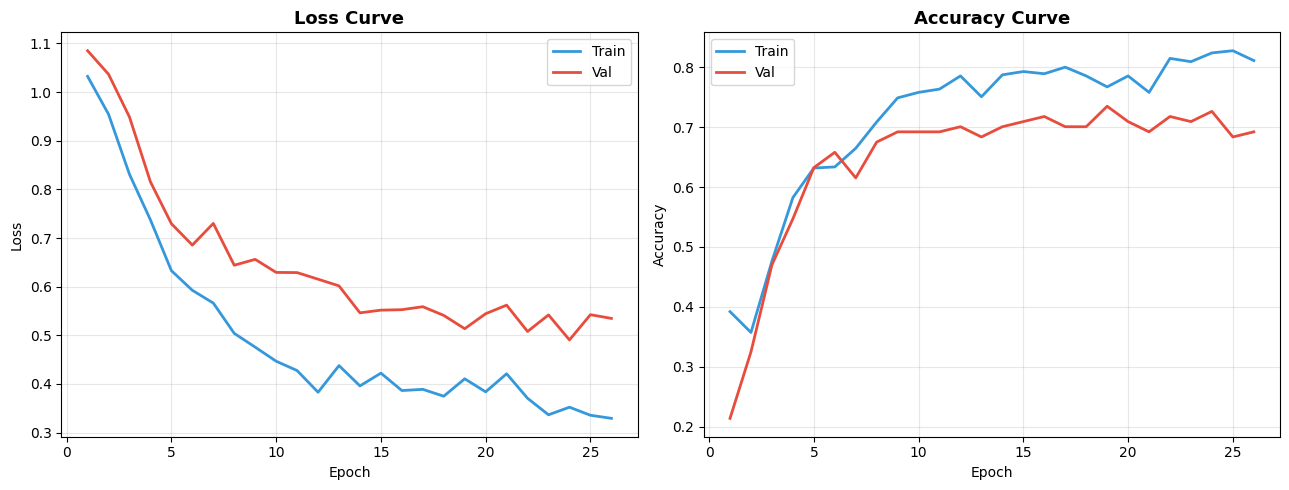

In [28]:
epochs_ran = range(1, len(history["train_loss"]) + 1)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(epochs_ran, history["train_loss"], label="Train", color="#3498db", lw=2)
axes[0].plot(epochs_ran, history["val_loss"],   label="Val",   color="#e74c3c", lw=2)
axes[0].set_title("Loss Curve", fontweight="bold", fontsize=13)
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss"); axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(epochs_ran, history["train_acc"], label="Train", color="#3498db", lw=2)
axes[1].plot(epochs_ran, history["val_acc"],   label="Val",   color="#e74c3c", lw=2)
axes[1].set_title("Accuracy Curve", fontweight="bold", fontsize=13)
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Accuracy"); axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig("training_curves.png", dpi=150, bbox_inches="tight")
plt.show()

In [29]:
model.load_state_dict(torch.load("best_model.pth", map_location=DEVICE))
model.eval()

all_labels, all_preds, all_probs = [], [], []

with torch.no_grad():
    for imgs, labels in test_loader:
        imgs   = imgs.to(DEVICE)
        logits = model(imgs)
        probs  = torch.softmax(logits, dim=1).cpu().numpy()
        preds  = logits.argmax(1).cpu().numpy()
        all_labels.extend(labels.numpy())
        all_preds.extend(preds)
        all_probs.extend(probs)

all_labels = np.array(all_labels)
all_preds  = np.array(all_preds)
all_probs  = np.array(all_probs)

In [30]:
print("=" * 60)
print("       CLASSIFICATION REPORT — TEST SET")
print("=" * 60)
print(classification_report(all_labels, all_preds,
                             target_names=[c.capitalize() for c in CLASSES],
                             digits=4))

       CLASSIFICATION REPORT — TEST SET
              precision    recall  f1-score   support

      Normal     0.6667    0.9000    0.7660        20
      Benign     0.9020    0.6970    0.7863        66
   Malignant     0.6154    0.7742    0.6857        31

    accuracy                         0.7521       117
   macro avg     0.7280    0.7904    0.7460       117
weighted avg     0.7858    0.7521    0.7562       117



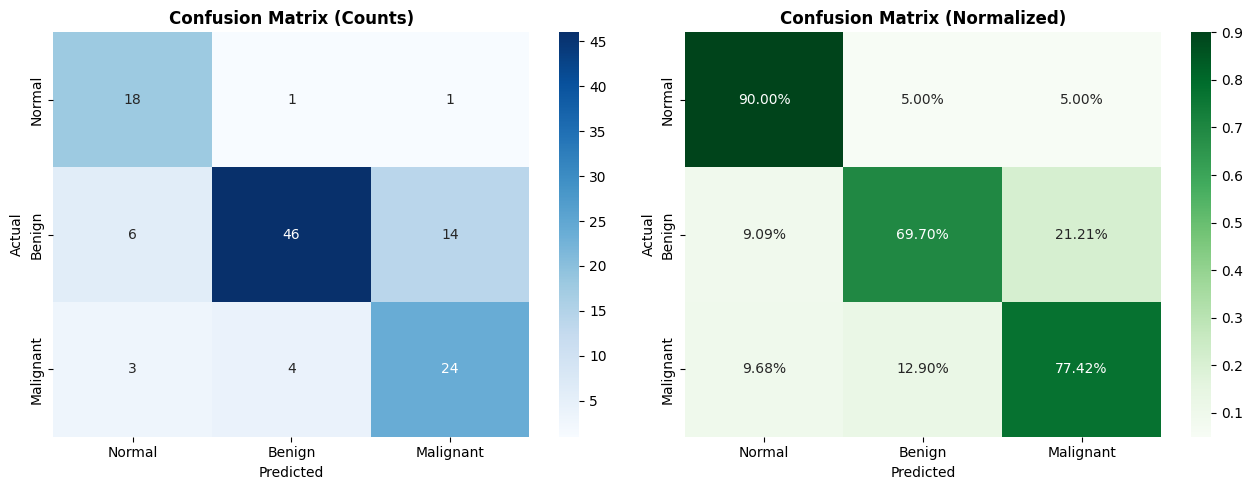

In [31]:
cm = confusion_matrix(all_labels, all_preds)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=[c.capitalize() for c in CLASSES],
            yticklabels=[c.capitalize() for c in CLASSES], ax=axes[0])
axes[0].set_title("Confusion Matrix (Counts)", fontweight="bold")
axes[0].set_xlabel("Predicted"); axes[0].set_ylabel("Actual")

cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
sns.heatmap(cm_norm, annot=True, fmt=".2%", cmap="Greens",
            xticklabels=[c.capitalize() for c in CLASSES],
            yticklabels=[c.capitalize() for c in CLASSES], ax=axes[1])
axes[1].set_title("Confusion Matrix (Normalized)", fontweight="bold")
axes[1].set_xlabel("Predicted"); axes[1].set_ylabel("Actual")

plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

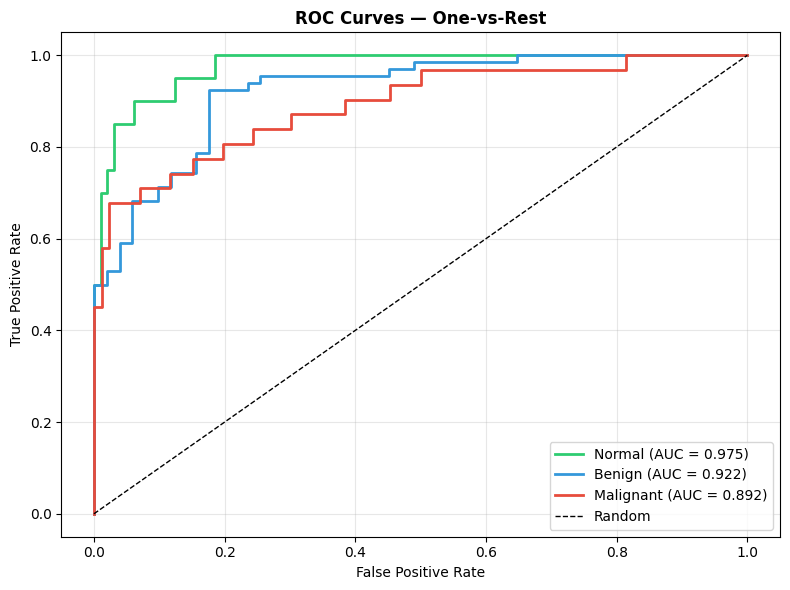

In [32]:
y_bin = label_binarize(all_labels, classes=[0, 1, 2])
colors_roc = ["#2ecc71", "#3498db", "#e74c3c"]

fig, ax = plt.subplots(figsize=(8, 6))
roc_aucs = {}

for i, (cls, col) in enumerate(zip(CLASSES, colors_roc)):
    fpr, tpr, _ = roc_curve(y_bin[:, i], all_probs[:, i])
    roc_auc_val  = auc(fpr, tpr)
    roc_aucs[cls] = roc_auc_val
    ax.plot(fpr, tpr, color=col, lw=2,
            label=f"{cls.capitalize()} (AUC = {roc_auc_val:.3f})")

ax.plot([0, 1], [0, 1], "k--", lw=1, label="Random")
ax.set_xlabel("False Positive Rate"); ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curves — One-vs-Rest", fontweight="bold")
ax.legend(loc="lower right"); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("roc_curves.png", dpi=150, bbox_inches="tight")
plt.show()

In [33]:
precision, recall, f1, support = precision_recall_fscore_support(
    all_labels, all_preds, labels=[0, 1, 2]
)

metrics_df = pd.DataFrame({
    "Class":     [c.capitalize() for c in CLASSES],
    "Precision": np.round(precision, 4),
    "Recall":    np.round(recall,    4),
    "F1-Score":  np.round(f1,        4),
    "AUC-ROC":   [round(roc_aucs[c], 4) for c in CLASSES],
    "Support":   support
})

print("=" * 60)
print("       PER-CLASS METRICS — TEST SET")
print("=" * 60)
print(metrics_df.to_string(index=False))

overall_acc  = (all_preds == all_labels).mean()
macro_f1     = f1.mean()
weighted_f1  = np.average(f1, weights=support)
macro_auc    = np.mean(list(roc_aucs.values()))

print(f"\n  Overall Accuracy  : {overall_acc:.4f}")
print(f"  Macro F1-Score    : {macro_f1:.4f}")
print(f"  Weighted F1-Score : {weighted_f1:.4f}")
print(f"  Macro AUC-ROC     : {macro_auc:.4f}")

       PER-CLASS METRICS — TEST SET
    Class  Precision  Recall  F1-Score  AUC-ROC  Support
   Normal     0.6667  0.9000    0.7660   0.9753       20
   Benign     0.9020  0.6970    0.7863   0.9225       66
Malignant     0.6154  0.7742    0.6857   0.8920       31

  Overall Accuracy  : 0.7521
  Macro F1-Score    : 0.7460
  Weighted F1-Score : 0.7562
  Macro AUC-ROC     : 0.9299


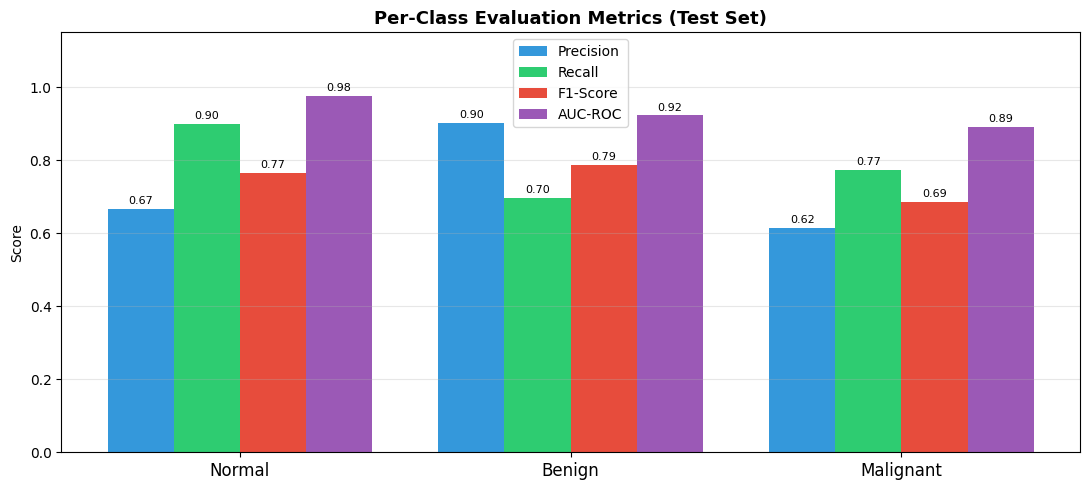

In [34]:
x     = np.arange(len(CLASSES))
width = 0.2

fig, ax = plt.subplots(figsize=(11, 5))
b1 = ax.bar(x - width*1.5, precision,                         width, label="Precision", color="#3498db")
b2 = ax.bar(x - width*0.5, recall,                            width, label="Recall",    color="#2ecc71")
b3 = ax.bar(x + width*0.5, f1,                                width, label="F1-Score",  color="#e74c3c")
b4 = ax.bar(x + width*1.5, [roc_aucs[c] for c in CLASSES],   width, label="AUC-ROC",   color="#9b59b6")

ax.set_xticks(x)
ax.set_xticklabels([c.capitalize() for c in CLASSES], fontsize=12)
ax.set_ylim(0, 1.15); ax.set_ylabel("Score"); ax.legend()
ax.set_title("Per-Class Evaluation Metrics (Test Set)", fontweight="bold", fontsize=13)
ax.grid(axis="y", alpha=0.3)
for container in ax.containers:
    ax.bar_label(container, fmt="%.2f", fontsize=8, padding=2)

plt.tight_layout()
plt.savefig("metrics_bar.png", dpi=150, bbox_inches="tight")
plt.show()

In [35]:
# Evaluate on full training set (inference mode, no augmentation)
train_eval_loader = DataLoader(
    BUSIDataset(train_df, val_test_transform),   # ← no augmentation
    batch_size=BATCH, shuffle=False, num_workers=2
)

model.eval()
tr_labels, tr_preds = [], []

with torch.no_grad():
    for imgs, labels in train_eval_loader:
        out = model(imgs.to(DEVICE))
        tr_preds.extend(out.argmax(1).cpu().numpy())
        tr_labels.extend(labels.numpy())

tr_labels = np.array(tr_labels)
tr_preds  = np.array(tr_preds)

train_acc = (tr_preds == tr_labels).mean()
print("=" * 60)
print("       CLASSIFICATION REPORT — TRAINING SET")
print("=" * 60)
print(classification_report(tr_labels, tr_preds,
                             target_names=[c.capitalize() for c in CLASSES],
                             digits=4))
print(f"  Training Accuracy : {train_acc:.4f}")

       CLASSIFICATION REPORT — TRAINING SET
              precision    recall  f1-score   support

      Normal     0.6718    0.9462    0.7857        93
      Benign     0.9513    0.7026    0.8083       306
   Malignant     0.7037    0.9048    0.7917       147

    accuracy                         0.7985       546
   macro avg     0.7756    0.8512    0.7952       546
weighted avg     0.8370    0.7985    0.8000       546

  Training Accuracy : 0.7985


In [36]:
print("\n" + "=" * 60)
print("           FINAL SUMMARY")
print("=" * 60)
summary = pd.DataFrame({
    "Split": ["Train", "Test"],
    "Accuracy":    [f"{train_acc:.4f}", f"{overall_acc:.4f}"],
    "Macro F1":    ["-",                f"{macro_f1:.4f}"],
    "Macro AUC":   ["-",                f"{macro_auc:.4f}"],
})
print(summary.to_string(index=False))
print("\n✅  All done!  Output files saved to working directory.")


           FINAL SUMMARY
Split Accuracy Macro F1 Macro AUC
Train   0.7985        -         -
 Test   0.7521   0.7460    0.9299

✅  All done!  Output files saved to working directory.
